In [1]:

from datetime import datetime

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import os
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import random
import seaborn as sns
from shapely.geometry import Point, Polygon
from datetime import timedelta
import torch.optim as optim
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import glob
# kasdfkhaflkj
plt.style.use('default')

torch.manual_seed(201894)
np.random.seed(201894)


In [2]:
tw = 48
sw = 22
min_data_points = 17

In [3]:


# function to generate rolling windows
def generate_windows(start_date, end_date, train_months, val_months):
    """
    Generate train/val windows from start to end date.
    Each window: 12m train + 3m val.
    """
    windows = []
    current = pd.to_datetime(start_date)

    while current + pd.DateOffset(months=train_months + val_months) < pd.to_datetime(end_date):
        train_start = current
        train_end   = current + pd.DateOffset(months=train_months)
        val_end     = train_end + pd.DateOffset(months=val_months)

        windows.append({
            "train_start": train_start,
            "train_end": train_end,
            "val_start": train_end,
            "val_end": val_end
        })

        # slide window forward (e.g. by 3 months, or 1 month depending on design)
        current = current + pd.DateOffset(months=3)

    return windows



In [4]:
output_dir = f'C:\\PROJECT-DEMETER\\Demeter_Retrain\\output_base\\Bg_window_data\\'
os.makedirs(output_dir, exist_ok=True)
output_dir_stat = f'C:\\PROJECT-DEMETER\\Demeter_Retrain\\output_base\\Bg_window_data\\stats\\'
os.makedirs(output_dir_stat, exist_ok=True)



In [5]:
seismic_counts_per_window = []

# Example: generate windows
windows_train = generate_windows(start_date="2005-01-01 00:00:00", end_date="2011-01-02 00:00:00",
                           train_months=12, val_months=3)
all_results =[]
for i, w in enumerate(windows_train):
    tag_l = f'tw{tw}_w{i}'
    df_train_labels =pd.read_csv(os.path.join(output_dir, f"summary_df_train_30D-22SW-{tag_l}.csv"))
    df_val_labels   =pd.read_csv(os.path.join(output_dir,f"summary_df_val_30D-22SW-{tag_l}.csv"))

    all_results.append({
    "window": i,
    "train_nonseismic": (df_train_labels["label"] == 0).sum(),
    "train_seismic": (df_train_labels["label"] == 1).sum(),
    "val_nonseismic": (df_val_labels["label"] == 0).sum(),
    "val_seismic": (df_val_labels["label"] == 1).sum(),
})

df_seis_counts = pd.DataFrame(seismic_counts_per_window)
print(df_seis_counts)


Empty DataFrame
Columns: []
Index: []


<>:98: SyntaxWarning: invalid escape sequence '\P'
<>:98: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_22572\875234539.py:98: SyntaxWarning: invalid escape sequence '\P'
  plt.savefig(f"C:\PROJECT-DEMETER\Paper1\Plots\Remote Sensing\PlotsR\\fig10.PNG", dpi=600, bbox_inches='tight')


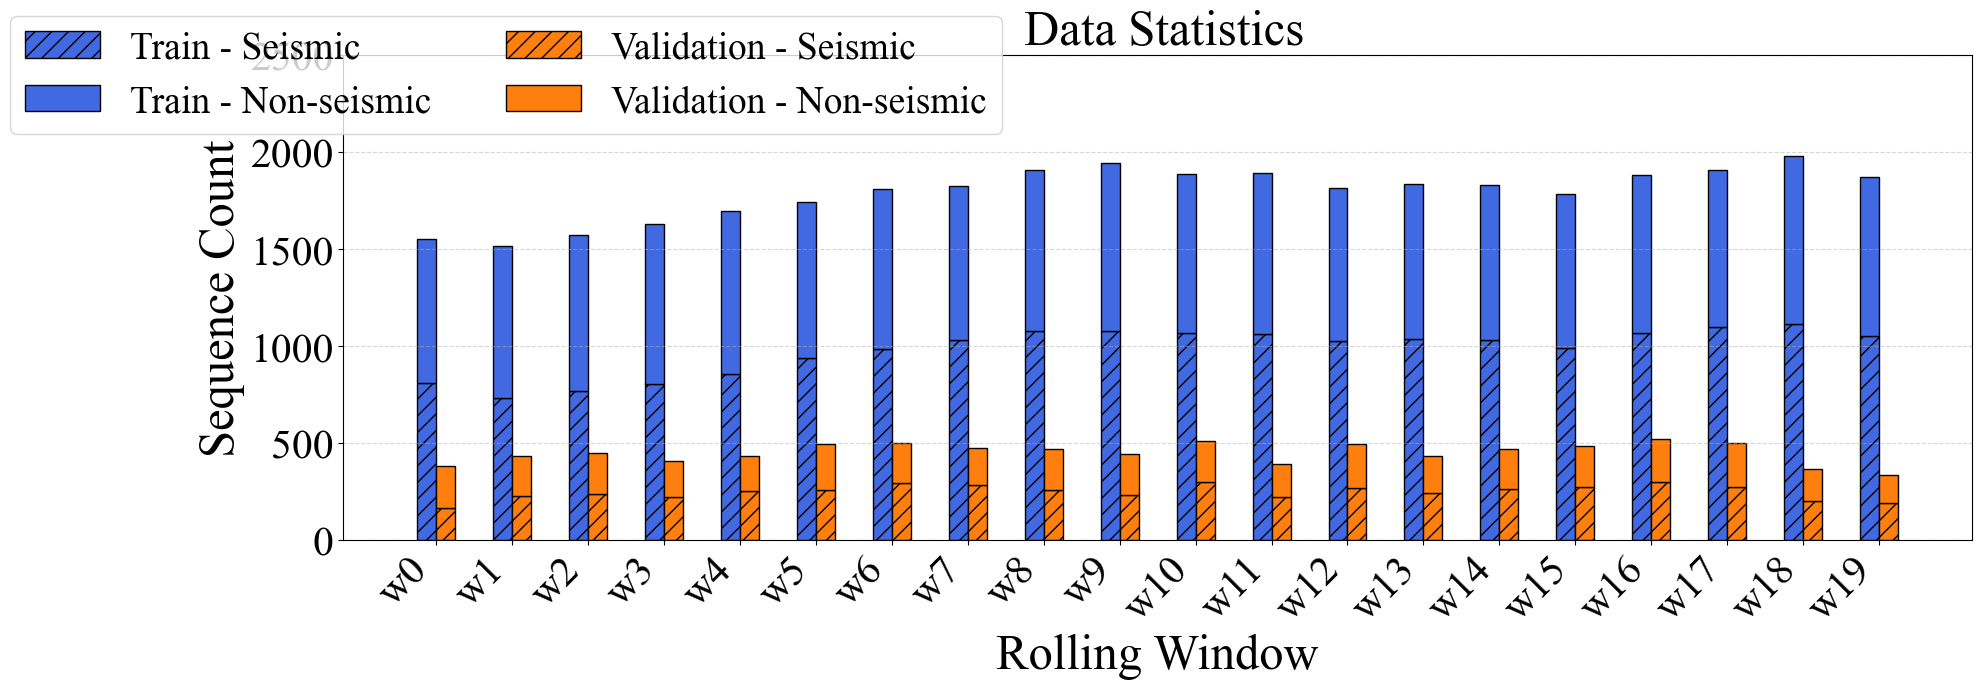

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl
mpl.rcParams.update({

        "font.family": "serif",
        "font.serif": ["Times New Roman"],

    })

# Example placeholder (replace with your real 'all_results')
df_plot = pd.DataFrame(all_results)

# --- Bar setup ---
spacing = 1.8  # increase this (e.g., 1.5, 2, 2.5)
x = np.arange(len(df_plot)) * spacing
width = 0.45  # bar width

plt.figure(figsize=(20, 7))

# --- TRAIN (Blue) ---
# Seismic BELOW (hatched)
plt.bar(x - width/2, df_plot["train_seismic"], width,
        color='royalblue', hatch='//', edgecolor='black', label='Train - Seismic')
# Non-seismic ABOVE (solid)
plt.bar(x - width/2, df_plot["train_nonseismic"], width, edgecolor='black',
        bottom=df_plot["train_seismic"],
        color='royalblue', label='Train - Non-seismic')

# --- VALIDATION (Dark Orange) ---
# Seismic BELOW (hatched)
plt.bar(x + width/2, df_plot["val_seismic"], width,
        color='#ff7f0e', hatch='//', edgecolor='black', label='Validation - Seismic')
# Non-seismic ABOVE (solid)
plt.bar(x + width/2, df_plot["val_nonseismic"], width, edgecolor='black',
        bottom=df_plot["val_seismic"],
        color='#ff7f0e', label='Validation - Non-seismic')

plt.xlabel("Rolling Window", fontsize=35)
plt.ylabel("Sequence Count", fontsize=35)
plt.title(fr" Data Statistics", fontsize=35)
plt.xticks(
    x,
    [f"w{w}" for w in df_plot["window"]], rotation=45, ha='right'
)

plt.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.1, 1.12),fontsize=27)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tick_params(axis='both', labelsize=30)
plt.tight_layout()
plt.ylim(0, 2500)


# --- Save and show ---
# plt.savefig(f"C:\PROJECT-DEMETER\Paper1\Plots\IEEE\\fig_8.png", dpi=600, bbox_inches='tight')
# plt.savefig(f"C:\PROJECT-DEMETER\Paper1\Plots\Remote Sensing\PlotsR\\fig10.PNG", dpi=600, bbox_inches='tight')

plt.show()
